In [3]:
import math
import matplotlib.pyplot as plt
import numpy as np
from typing import Literal

from graphviz import Digraph

In [2]:
def f(x):
    return 3*x**2 - 4*x + 5

In [3]:
f(3.0)

20.0

In [4]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)

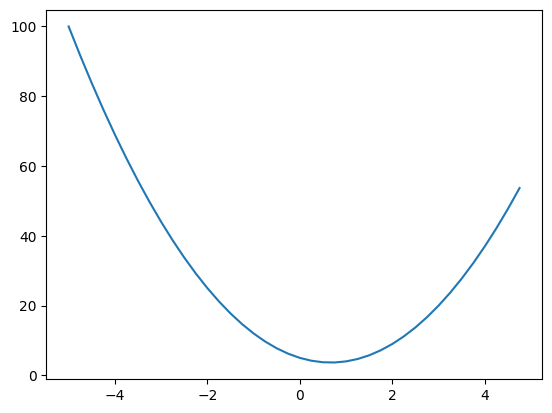

In [5]:
plt.plot(xs, ys)
#plt.vlines(x, 40, 50, colors='red')

In [6]:
h = 0.00000000000001
x = 2/3
(f(x + h) - f(x))/h

0.0

In [7]:
h = 0.0001

a = 2.0
b = -3.0
c = 10.0
d = a*b + c

d1 = a*b + c
a += h
d2 = a*b + c

print('d1', d1)
print('d2')
print('slope', (d2-d1)/h)

d1 4.0
d2
slope -3.000000000010772


In [4]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f'Value(data={self.data})'
    
    def __add__(self, other):
        other = other  if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward

        return out
    
    def __radd__(self, other):
        return self if other == 0 else self + other
    
    def __mul__(self, other):
        other = other  if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward

        return out
    
    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self, ), f'**{other}')

        def _backward():
            self.grad += other * (self.data ** (other - 1)) * out.grad
        out._backward = _backward

        return out
    
    def __rmul__(self, other):
        return self * other
    
    def __truediv__(self, other):
        return self * other**-1
    
    def __neg__(self):
        return self * -1
    
    def __sub__(self, other):
        return self + (-other)
    
    def tanh(self):
        x = self.data
        t = (math.exp(2 * x) - 1)/(math.exp(2 * x) + 1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        
        return out
    
    def sigmoid(self):
        x = self.data
        t = 1/(1 + math.exp(-x))
        out = Value(t, (self, ), 'sigmoid')

        def _backward():
            self.grad += (t * (1 - t)) * out.grad
        out._backward = _backward

        return out
    
    def relu(self, alpha=0.01):
        t = self.data if self.data > 0 else alpha * self.data
        out = Value(t, (self, ), 'relu')

        def _backward():
            derivative = 1 if self.data > 0 else alpha
            self.grad += derivative * out.grad
        out._backward = _backward

        return out
    
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')

        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward

        return out
    
    def backward(self):

        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()
    

In [9]:
def sig(x):
    return 1/(1 + math.exp(-x))

sig(5000000000)

1.0

In [9]:
a = Value(2.0)
b = Value(4.0)

a - b

Value(data=-2.0)

In [10]:
# build a graph to visualize the operation

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # 'LR' = left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        # grad is the backpropagation value, i.e. the derivative w.r.o. L
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name=uid + n._op, label=n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connec n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

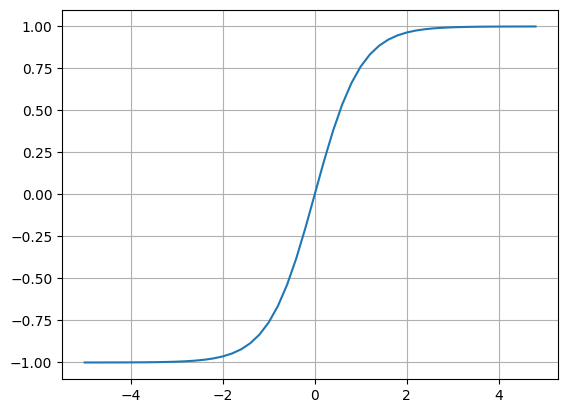

In [11]:
plt.plot(np.arange(-5, 5, 0.2), np.tanh(np.arange(-5,5,0.2)))
plt.grid()

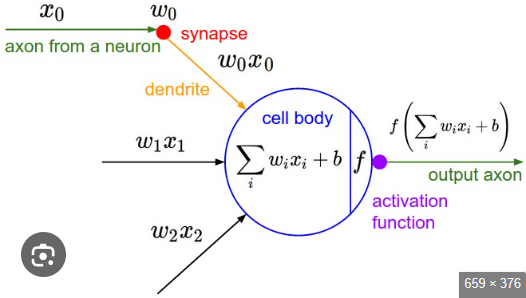

In [12]:
# inputs x1, x1
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias
b = Value(6.8812381236, label='b')

x1w1 = x1*w1; x1w1.label='x1w1'
x2w2 = x2*w2; x2w2.label='x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label='x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

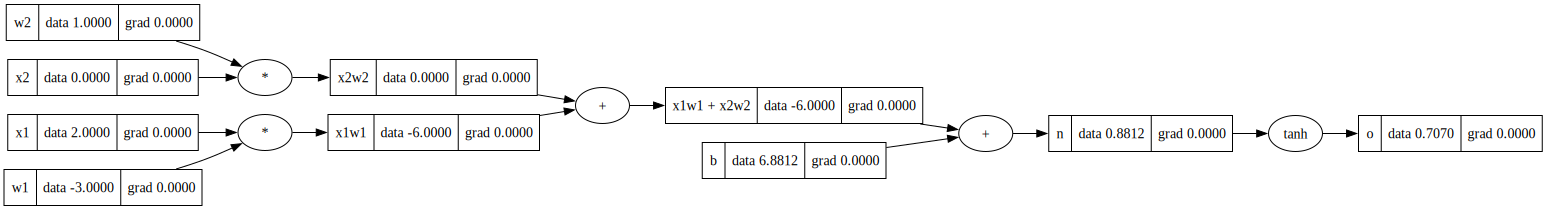

In [13]:
draw_dot(o)

In [14]:
o.backward()

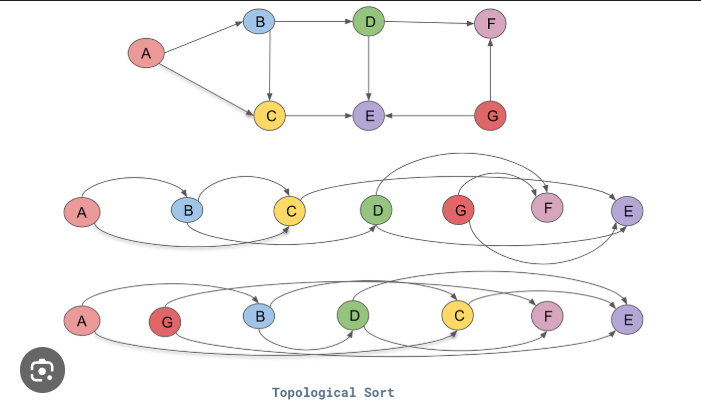

In [15]:
# building a topological list

topo = []
visited = set()
def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)
build_topo(o)
topo

[Value(data=1.0),
 Value(data=0.0),
 Value(data=0.0),
 Value(data=-3.0),
 Value(data=2.0),
 Value(data=-6.0),
 Value(data=-6.0),
 Value(data=6.8812381236),
 Value(data=0.8812381236000002),
 Value(data=0.7070390429887448)]

In [115]:
# backpropagating with the topological list

o.grad = 1.0

topo = []
visited = set()
def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)
build_topo(o)

for node in reversed(topo):
    node._backward()

In [ ]:
### CALCULATING THE BACKPROP FLOW WITH _backprop()

# o.grad = 1.0
# o._backward()
# n._backward()
# b._backward()
# x1w1x2w2._backward()
# x2w2._backward()
# x1w1._backward()

In [ ]:
### CALCULTAING THE BACKPROP FLOW BY HAND

#o.grad = 1.0
#1 - o.data**2
#n.grad = 1 - o.data**2
# x1w1x2w2.grad = 0.5
# b.grad = 0.5
# x1w1.grad = 0.5
# x2w2.grad = 0.5
# x2.grad = w2.data * x2w2.grad
# w2.grad = x2.data * x2w2.grad
# x1.grad = w1.data * x1w1.grad
# w1.grad = x1.data * x1w1.grad

In [151]:
# inputs x1, x1
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias
b = Value(6.8812381236, label='b')

x1w1 = x1*w1; x1w1.label='x1w1'
x2w2 = x2*w2; x2w2.label='x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label='x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'
# o = n.tanh(); o.label = 'o'
#-- break tanh out:
e = (2*n).exp()
o = (e - 1) / (e + 1)

o.label = 'o'

o.backward()

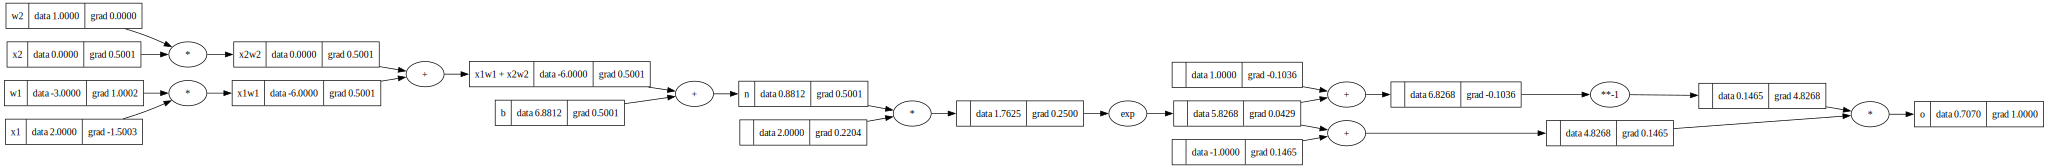

In [152]:
draw_dot(o)

In [1]:
# same thing implemented with pytorch
import torch

x1 = torch.Tensor([2.0]).double() ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double() ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double() ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double() ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double() ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('xw2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())


0.7071066904050358
---
x2 0.5000001283844369
xw2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [5]:
import random

class Neuron:

    def __init__(self, nin, activation: Literal['tanh', 'sigmoid', 'relu'] = 'tanh'):
        # a neuron has nin inputs (nin weights) and one bias
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1))
        self.activation = activation

    def __call__(self, x, ):
        # calculates the sum of products of weights and inputs + bias
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        # applies the non-linearity
        if self.activation == 'tanh':
            out = act.tanh()
        elif self.activation == 'sigmoid':
            out = act.sigmoid()
        elif self.activation == 'relu':
            out = act.relu()
        return out
    
    def parameters(self):
        return self.w + [self.b]
    
class Layer:

    def __init__(self, nin, nout, activation: Literal['tanh', 'sigmoid', 'relu'] = 'tanh'):
        # layer is nout number of nin input Neurons in a list
        # example: Layer(3,4) 4 neurons with 3 inputs (weights) and 1 bias
        self.neurons = [Neuron(nin, activation) for _ in range(nout)]

    def __call__(self, x):
        # feeds the same input vector to each neuron and collects their output
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs
    
    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]
    
class MLP:

    def __init__(self, nin, nouts, activation: Literal['tanh', 'sigmoid', 'relu'] = 'tanh'):
        # example Layer(3, [4,4,1]) : Layer of 3 inputs, 4 neurons, 4 neurons, 1 neuron
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1], activation) for i in range(len(nouts))]
        # sz = [3,4,4,1] -> connects layer(3 -> 4), layer(4 -> 4), layer(4 -> 1)

    def __call__(self, x):
        # function composition: f(x) = L3(L2(L1(x))), each layer transforms
        # the input and hands it to the next
        for layer in self.layers:
            x = layer(x)
        return x
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

In [51]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4,4,1], 'tanh')
n(x)

Value(data=0.6153340997290176)

In [52]:
xs = [
    [2.0, 3.0,-1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets

ypred = [n(x) for x in xs]
ypred

[Value(data=0.6153340997290176),
 Value(data=0.23517102548804406),
 Value(data=0.4540817357452748),
 Value(data=0.4068781187452903)]

In [ ]:
for i in range(8000):
    # forward pass
    ypred = [n(x) for x in xs]
    loss = sum(((yout - ygt)**2 for ygt, yout in zip(ys, ypred)))

    # backward pass
    # zero grads (or they will just add up)
    for p in n.parameters():
        p.grad = 0.0
    loss.backward()

    # update
    for p in n.parameters(): 
        p.data += -0.05 * p.grad
    
    print(i, loss.data)

In [54]:
ypred

[Value(data=0.9945700814598903),
 Value(data=-0.9971199991068402),
 Value(data=-0.9918550773766562),
 Value(data=0.9934148633230273)]

In [157]:
loss = sum(((yout - ygt)**2 for ygt, yout in zip(ys, ypred)))
print(loss)
#loss.backward()
#n.layers[0].neurons[0].w[0].grad

Value(data=4.0)


In [ ]:
# update values
for p in n.parameters():
    p.data += -0.01 * p.grad

In [220]:
# GRADIENT DESCENT
'''
loss started here:
loss = sum(((yout - ygt)**2 for ygt, yout in zip(ys, ypred)))
print(loss)
>>> Value(data=3.853499603920143)
'''
ypred = [n(x) for x in xs]
loss = sum(((yout - ygt)**2 for ygt, yout in zip(ys, ypred)))
print(loss)

loss.backward()

for p in n.parameters(): 
    p.data += -0.01 * p.grad

Value(data=4.008522716675155)


In [221]:
ypred

[Value(data=-0.010664448066284535),
 Value(data=-0.00788218608740785),
 Value(data=-0.00842199635892117),
 Value(data=-0.009730358116709963)]

In [268]:
losses = []

for i in range(1000):
    ypred = [n(x) for x in xs]
    loss = sum(((yout - ygt)**2 for ygt, yout in zip(ys, ypred)))
    print(f'step {i}, loss: {loss.data}')
    if loss.data < 0.001:
        break

    loss.backward()
    losses.append(loss.data)

    for p in n.parameters(): 
        p.data += -0.01 * p.grad

step 0, loss: 3.6618412949672163
step 1, loss: 2.6424615659825292
step 2, loss: 1.3582211734410239
step 3, loss: 0.8355832413114568
step 4, loss: 0.5872098529424743
step 5, loss: 0.36425920729537437
step 6, loss: 0.19383304984917119
step 7, loss: 0.0943562847415461
step 8, loss: 0.04729543928651689
step 9, loss: 0.026533300913823117
step 10, loss: 0.016836445642539544
step 11, loss: 0.011769067698814119
step 12, loss: 0.008768832336509255
step 13, loss: 0.006766675859351074
step 14, loss: 0.005288673407564986
step 15, loss: 0.004117873447641131
step 16, loss: 0.0031559978792896053
step 17, loss: 0.002360407589529917
step 18, loss: 0.0017124141044210259
step 19, loss: 0.0012005647430991247
step 20, loss: 0.0008123308065963127


In [270]:
len(losses)

20

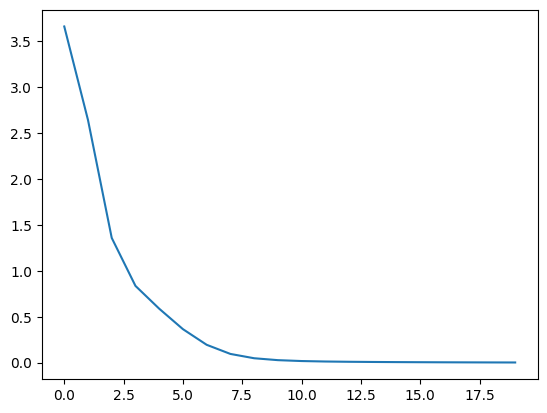

In [272]:
plt.plot(range(20), losses)